# 9. Forces and structural relaxation

Everything up to here answered *what is the energy of this arrangement of atoms*. This
notebook answers the next question — **which way should the atoms move** — and then moves
them until they stop.

The force on an atom is minus the derivative of the total energy with respect to its
position, so in a code written in JAX it ought to be one line. It very nearly is, and the
interesting part is the argument for why that line is *correct*: the energy is not an
explicit function of the positions, it is the value at a fixed point that had to be found
by iteration, and differentiating a fixed-point search is not the same thing as
differentiating the fixed point.

1. why the force is a partial derivative and not a total one, and what each term of the
   energy contributes;
2. the identity that has to hold before anything is differentiated;
3. the force on silicon, against Quantum ESPRESSO and against finite differences;
4. Quantum ESPRESSO's six hand-derived terms, transcribed, and what comparing them found;
5. what separates the two methods — and it is a known quantity, not noise;
6. relaxation: BFGS, a trust radius, and diamond silicon putting itself back together;
7. a molecule with a frozen atom, and the traps a moving geometry sets.

In [1]:
from pathlib import Path

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from pypresso.forces import compute_forces, frozen_energy, state_from_result
from pypresso.io import read_qe_output
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.scf.driver import Calculation
from pypresso.system import build_system
from pypresso.workflows import run_relax

CASES = Path('../tests/data/qe')
PSEUDO = Path('../tests/data/pseudo')

def load(case):
    system = build_system(read_pw_input(CASES / f'{case}.in'))
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    return system, pseudos

def reference(case):
    return read_qe_output(CASES / f'reference.out.{case}')

## 1. The force is a partial derivative

The total energy of a converged calculation depends on the atomic positions **twice**:
explicitly, through the pseudopotentials and the Ewald sum that sit at the atoms, and
implicitly, through the wavefunctions and the density that the SCF found *for* those
positions. The chain rule wants both:

    dE/dtau = (partial E / partial tau) + (partial E / partial psi)(d psi / d tau) + ...

The second group of terms is the expensive one — it needs the response of the
wavefunctions to a displacement, which is a linear-response calculation in its own right.
It is also **zero**, and that is the entire reason forces are cheap. At the converged
solution the energy is stationary with respect to the wavefunctions and the density: any
first-order change in them, subject to the wavefunctions staying orthonormal, leaves the
energy unchanged. So the total derivative equals the partial one, taken at *frozen*
wavefunctions, occupations and eigenvalues.

"Subject to staying orthonormal" is not a footnote. For an ultrasoft or PAW dataset the
orthonormality condition is `<psi|S(tau)|psi> = 1` and **S depends on the positions**, so
the constraint itself moves when an atom does. The functional that is differentiated
therefore carries the constraint with its Lagrange multipliers at their converged values,

    E[psi, tau] = kinetic + <psi|V_NL(tau)|psi> + int vltot(tau) rho + E_H + E_xc + E_Ewald(tau)
                  - sum_kn w f eps (<psi|S(tau)|psi> - 1),

and that last line — identically zero at the solution, with a derivative that is not — is
what QE writes by hand as the `eps <psi|dS|psi>` half of `force_us`. Leave it out and a
norm-conserving force is perfect while an ultrasoft one is wrong by a few per cent.

Two things are deliberately *not* separate terms. `D_ij` is not an input to the functional:
its self-consistent part is `int V_eff Q_ij`, which is already there through the
augmentation charge inside `rho`, so the nonlocal term takes the **bare** `dion` from the
pseudopotential file and nothing is counted twice. And there is no "SCF correction" term —
QE has one because its density stops short of the fixed point, and this functional assumes
the fixed point. Section 5 measures exactly that difference.

## 2. The identity that comes before the derivative

`frozen_energy` reassembles the total energy out of different pieces than the SCF driver
uses: the bare `D_ij` instead of the self-consistent one, the augmentation charge inside
the density instead of inside `deeq`, and a constraint term that the driver has no need
for. If the reassembly is wrong, its gradient is the derivative of something else — a
plausible number with no way to tell.

So the first thing to check is not a force at all. It is that the functional, evaluated at
the geometry the SCF converged at, gives the SCF's own total energy.

In [2]:
gate = {}
for case in ['si2-nc-force', 'si2-us-force', 'si2-paw-force', 'si2-us-pbe-force']:
    system, pseudos = load(case)
    calculation = Calculation(system, pseudos)
    scf = run_scf(system, pseudos, calculation=calculation, conv_thr=1e-10)
    energy = frozen_energy(calculation, system.structure.positions, state_from_result(scf))
    gate[case] = (scf.total_energy, float(energy))

print(f"{'case':18s} {'SCF total (Ry)':>18s} {'frozen functional':>18s} {'difference':>12s}")
for case, (scf_energy, functional) in gate.items():
    print(f'{case:18s} {scf_energy:18.10f} {functional:18.10f} {functional - scf_energy:12.1e}')

case                   SCF total (Ry)  frozen functional   difference
si2-nc-force           -15.7874037087     -15.7874037086      1.0e-10
si2-us-force           -22.7454400458     -22.7454400458      3.5e-13
si2-paw-force          -89.2668867248     -89.2668867248      1.4e-12
si2-us-pbe-force       -22.8143892009     -22.8143892001      7.8e-10


Machine precision on all four — norm-conserving, ultrasoft, PAW and PBE. The cancellation
that makes this work is worth writing out once, because it is the whole argument for the
shape of the functional. QE's decomposition is

    E = eband + deband + E_H + E_xc + E_Ewald,

with `eband = sum w f eps` the sum of occupied eigenvalues and `deband = -int rho v_scf`
(minus, for PAW, `sum ddd_paw becsum`) removing what that double-counts. Substituting
`eps = <psi| T + vltot + v_scf + V_NL^deeq |psi>` and expanding `deeq = dion + int V_eff Q`
makes the self-consistent potential cancel term by term, and what is left is the kinetic
energy, the **bare** nonlocal energy, and `int vltot rho` over the *augmented* density.
Which is the functional above.

## 3. The force on silicon

The test case is the two-atom cell with one atom pushed 0.02 alat along x. The displacement
lowers the symmetry from 48 operations to 8, and those 8 are enough to forbid any force
component except along x — so the comparison against Quantum ESPRESSO checks the size of
the force *and* the code's symmetry handling at the same time.

In [3]:
system, pseudos = load('si2-nc-force')
calculation = Calculation(system, pseudos)
scf = run_scf(system, pseudos, calculation=calculation, conv_thr=1e-10)
forces = compute_forces(calculation, scf)          # autodiff, the default
qe = reference('si2-nc-force')

print('symmetry operations of the displaced crystal:', calculation.symmetries.nsym)
print()
print(f"{'atom':>4s} {'pypresso (Ry/bohr)':>38s} {'Quantum ESPRESSO':>38s}")
for atom, (ours, theirs) in enumerate(zip(forces.forces, qe.forces)):
    print(f'{atom:4d}  ' + ' '.join(f'{v: .8f}' for v in ours)
          + '   ' + ' '.join(f'{v: .8f}' for v in theirs))
print()
print(f'largest difference   {np.abs(forces.forces - qe.forces).max():.2e} Ry/bohr')
print(f'sum of forces before it was removed  {np.abs(forces.total_before_correction).max():.1e}')

symmetry operations of the displaced crystal: 8

atom                     pypresso (Ry/bohr)                       Quantum ESPRESSO
   0   0.06039736 -0.00000000  0.00000000    0.06039673  0.00000000  0.00000000
   1  -0.06039736  0.00000000 -0.00000000   -0.06039673  0.00000000  0.00000000

largest difference   6.26e-07 Ry/bohr
sum of forces before it was removed  1.5e-05


Two lines of that output are not about agreement with QE.

The **y and z components are exactly zero** rather than small. That is the symmetrisation
(`symvector`): a Brillouin-zone sum over the irreducible wedge is exact for a scalar and
not for a vector, so a force built from a reduced k-set has components along directions the
crystal forbids. Averaging over the group projects them out. On the *undisplaced* crystal
the same projection kills the whole force — diamond's atoms sit at a fixed point of the
symmetry, so no force is allowed at all, and the number that comes out is zero to 1e-16
rather than 1e-4.

The **sum over atoms** is the acoustic sum rule: translating the whole crystal cannot
change its energy, but nothing in the discretised energy knows that, so what survives is
the error made by the FFT grid and the cutoff. QE subtracts its average and so does this
code — after keeping it, because it is a convergence diagnostic before it is a nuisance.

### The check that trusts nothing

Everything so far compares two codes that could in principle share a misconception. The
finite-difference check does not: it converges the SCF at three geometries and differences
the total energies, using nothing but the energy the previous notebooks already validated.

It has to run with `nosym`. Moving one atom along one axis breaks the symmetry of the
starting structure, and the symmetry group is deliberately *held fixed* while the atoms
move (section 7), so a symmetrised run would compare against a density symmetrised with
operations the displaced structure no longer has.

In [4]:
import dataclasses

unsymmetric = dataclasses.replace(system, nosym=True)
plain = Calculation(unsymmetric, pseudos)
scf_plain = run_scf(unsymmetric, pseudos, calculation=plain, conv_thr=1e-12)
autodiff = compute_forces(plain, scf_plain).forces

def energy_at(positions):
    moved = plain.at_positions(jnp.asarray(positions))
    return run_scf(moved.system, pseudos, calculation=moved, conv_thr=1e-12).total_energy

h = 2.0e-3
origin = np.asarray(unsymmetric.structure.positions)
print(f"{'coordinate':>12s} {'finite difference':>20s} {'autodiff':>16s} {'difference':>13s}")
for atom, direction in [(0, 0), (0, 1), (1, 2)]:
    plus, minus = origin.copy(), origin.copy()
    plus[atom, direction] += h
    minus[atom, direction] -= h
    fd = -(energy_at(plus) - energy_at(minus)) / (2 * h)
    ad = autodiff[atom, direction]
    print(f'  atom {atom} {"xyz"[direction]}   {fd:20.8f} {ad:16.8f} {fd - ad:13.1e}')

  coordinate    finite difference         autodiff    difference


  atom 0 x             0.06076082       0.06076358      -2.8e-06


  atom 0 y            -0.00470094      -0.00470190       9.5e-07


  atom 1 z             0.01005466       0.01005364       1.0e-06


Agreement at the 1e-6 level, which is the truncation error of a central difference at this
step size and not a property of the force. Note what this test would have caught and the
QE comparison would not: any error the two codes make in common.

## 4. The same force, the way Quantum ESPRESSO computes it

`PW/src/forces.f90` calls six routines, each of which differentiates one term by hand:
`force_ew` (the ions' electrostatics), `force_lc` (the local pseudopotential moving through
the density), `force_cc` (the core charge moving through `v_xc`), `force_us` (the
projectors moving, with `deff = deeq - eps qq`), `addusforce` (the augmentation charge's
own derivative), and `force_corr` (a correction for a density that stopped short). All six
are transcribed in `pypresso/forces/analytic.py`, and the run below asks for them
explicitly.

Running both is not redundancy for its own sake. The two share no machinery, so they fail
in different ways — and the term-by-term comparison against QE's own breakdown
(`verbosity = 'high'`) is sharper still, because a total force can be right with two terms
wrong in opposite directions.

In [5]:
system_us, pseudos_us = load('si2-us-force')
calc_us = Calculation(system_us, pseudos_us)
scf_us = run_scf(system_us, pseudos_us, calculation=calc_us, conv_thr=1e-10)
qe_us = reference('si2-us-force')

analytic = compute_forces(calc_us, scf_us, method='analytic')
autodiff_us = compute_forces(calc_us, scf_us, method='autodiff')

from pypresso.system.symmetry import atom_mapping, symmetrize_vector
mapping = atom_mapping(system_us.cell, system_us.structure, calc_us.symmetries)
def symmetrised(vector):
    return np.asarray(symmetrize_vector(np.asarray(vector), system_us.cell,
                                        calc_us.symmetries, mapping))

terms = dict(analytic.terms)
terms['nonlocal'] = terms['nonlocal'] + terms.pop('augmentation')   # QE folds it in
print(f"{'term':>16s} {'pypresso (x, atom 1)':>22s} {'Quantum ESPRESSO':>20s} {'difference':>12s}")
for name, qe_name in [('ewald', 'ionic'), ('local', 'local'),
                      ('core', 'core'), ('nonlocal', 'nonlocal'),
                      ('scf_correction', 'scf_correction')]:
    ours = symmetrised(terms[name])
    theirs = qe_us.force_terms[qe_name]
    print(f'{name:>16s} {ours[0, 0]:22.8f} {theirs[0, 0]:20.8f} '
          f'{np.abs(ours - theirs).max():12.1e}')
print()
print(f'total, analytic vs QE   {np.abs(analytic.forces - qe_us.forces).max():.1e} Ry/bohr')
print(f'total, autodiff vs QE   {np.abs(autodiff_us.forces - qe_us.forces).max():.1e} Ry/bohr')

            term   pypresso (x, atom 1)     Quantum ESPRESSO   difference
           ewald             0.10209222           0.10209221      1.1e-08
           local            -0.10041989          -0.10042054      6.5e-07
            core            -0.00600235          -0.00600313      7.8e-07
        nonlocal             0.06307401           0.06307509      1.1e-06
  scf_correction             0.00000007          -0.00000028      4.0e-07

total, analytic vs QE   2.0e-07 Ry/bohr
total, autodiff vs QE   1.3e-07 Ry/bohr


Writing both found two things, and neither would have been visible in the total alone.

**The augmentation force had the wrong sign.** `addusforce` came out as `-Omega sum G ...`
where it should be `+`, which moved the *nonlocal* term (QE folds `addusforce` into it) by
0.029 Ry/bohr — half of the term itself. The autodiff force, which never writes that
expression, was right; the disagreement between the two is what pointed at it.

**`force_cc` needs the gradient correction, and it looks as though it does not.** QE's
`force_cc` calls `v_xc` and the gradient correction appears to be added separately by
`v_of_rho` — it is not. `gradcorr` is called from *inside* `v_xc`
(`PW/src/v_of_rho.f90`, line 607, within the routine that begins at line 440), and that is
the only call to it in all of `PW/src`. Building the core-charge force from the local part
alone leaves silicon's `force_cc` wrong by 9e-4 Ry/bohr — a thousand times the agreement
every other term reaches. Again the autodiff force had it right, because differentiating an
energy cannot leave out a piece of that energy.

That is the argument for having both, in one paragraph: the hand-derived expressions are
QE's, and checking them against a derivative that no one wrote down is a stronger test than
either could be alone.

## 5. What separates the two methods

They should not agree exactly, and the amount by which they differ is not noise. The
analytic force has `force_corr` — Chan, Bohnen and Ho's correction for a density that has
not quite reached the fixed point — and the autodiff force cannot have it, because it
differentiates the energy *at* a fixed point it assumes.

So the difference between the two methods should be that term, and should vanish as the SCF
is converged harder. That is a prediction, and it is cheap to test.

  conv_thr     |force_corr|    |analytic - autodiff|
     1e-06         1.08e-05                 1.08e-05
     1e-08         9.47e-07                 9.47e-07
     1e-10         7.97e-07                 7.97e-07
     1e-12         3.32e-08                 3.32e-08


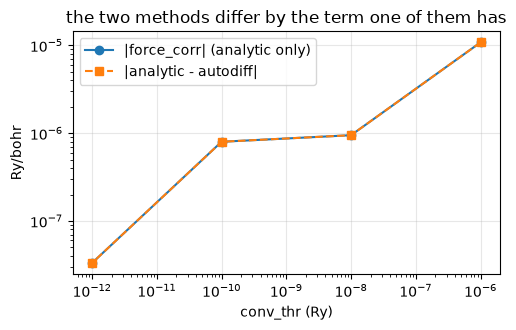

In [6]:
thresholds = [1e-6, 1e-8, 1e-10, 1e-12]
rows = []
for threshold in thresholds:
    run = run_scf(system, pseudos, calculation=calculation, conv_thr=threshold)
    a = compute_forces(calculation, run, method='analytic')
    b = compute_forces(calculation, run, method='autodiff')
    rows.append((threshold,
                 np.abs(a.terms['scf_correction']).max(),
                 np.abs(a.forces - b.forces).max()))

print(f"{'conv_thr':>10s} {'|force_corr|':>16s} {'|analytic - autodiff|':>24s}")
for threshold, correction, gap in rows:
    print(f'{threshold:10.0e} {correction:16.2e} {gap:24.2e}')

fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.loglog([r[0] for r in rows], [r[1] for r in rows], 'o-', label='|force_corr| (analytic only)')
ax.loglog([r[0] for r in rows], [r[2] for r in rows], 's--', label='|analytic - autodiff|')
ax.set_xlabel('conv_thr (Ry)'); ax.set_ylabel('Ry/bohr')
ax.set_title('the two methods differ by the term one of them has')
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()

The two curves lie on top of each other and both fall with `conv_thr`. The difference
between the methods *is* the SCF correction term — which also makes `force_corr` a useful
number to look at on its own: it is a direct measure of how converged a run is, expressed in
the units of the quantity you actually wanted.

## 6. Relaxation

With a force, moving the atoms is an optimisation problem with an expensive gradient: each
evaluation is a converged SCF. QE uses BFGS with a trust radius and a Wolfe-condition line
search (`Modules/bfgs_module.f90`), and `pypresso/relax/bfgs.py` is that algorithm, working
in crystal coordinates with the cell metric.

Two details of it are worth knowing, because they are what make it behave on a real
surface rather than a textbook one.

**The step length is measured per atom.** QE's `scnorm` is the *largest single atom's*
displacement, not the norm of the whole configuration vector, so `trust_radius_max = 0.8`
means "no atom moves more than 0.8 bohr" whatever the cell holds and however many atoms
are in it.

**The Hessian update is damped.** `s . y < 0` is impossible for a quadratic with a positive
definite Hessian and routine in a real relaxation where bonds are forming and breaking. The
undamped update would then produce an indefinite inverse Hessian and a step that goes
uphill; QE's "curvature trap" (Nocedal and Wright §18.2) replaces `y` by a combination of
`y` and `B s` that restores the condition.

The test is silicon, displaced 0.02 alat off its site. The answer is known before the
calculation starts: diamond's second atom sits at (1/4, 1/4, 1/4) and nowhere else.

In [7]:
system_relax, pseudos_relax = load('si2-nc-relax')
relaxed = run_relax(system_relax, pseudos_relax, conv_thr=1e-10)
alat = float(system_relax.cell.alat)

print(f"{'step':>5s} {'total energy (Ry)':>20s} {'max |F| (Ry/bohr)':>19s} "
      f"{'separation (alat)':>19s} {'scf iterations':>15s}")
for step in relaxed.steps:
    separation = (step.positions[1] - step.positions[0]) / alat
    print(f'{step.index:5d} {step.total_energy:20.8f} {step.max_force:19.6f}'
          f'   ({separation[0]:.4f}, {separation[1]:.4f}, {separation[2]:.4f})'
          f' {step.scf_iterations:10d}')

qe_relax = reference('si2-nc-relax')
print()
print(f'converged in {relaxed.nsteps} ionic steps '
      f'(Quantum ESPRESSO: {qe_relax.bfgs_steps[0]} scf cycles, {qe_relax.bfgs_steps[1]} bfgs steps)')
print(f'final energy   pypresso {relaxed.total_energy:.10f}   QE {qe_relax.final_energy:.10f}'
      f'   difference {relaxed.total_energy - qe_relax.final_energy:.1e} Ry')
print(f'final geometry differs from QE by {np.abs(relaxed.positions - qe_relax.final_positions).max():.1e} bohr')

 step    total energy (Ry)   max |F| (Ry/bohr)   separation (alat)  scf iterations
    1         -15.78740371            0.060397   (0.2700, 0.2500, 0.2500)          7
    2         -15.79256155            0.024847   (0.2582, 0.2500, 0.2500)          7
    3         -15.79359588            0.000366   (0.2499, 0.2500, 0.2500)          7
    4         -15.79359610            0.000001   (0.2500, 0.2500, 0.2500)          5

converged in 4 ionic steps (Quantum ESPRESSO: 4 scf cycles, 3 bfgs steps)
final energy   pypresso -15.7935961045   QE -15.7935961042   difference -2.8e-10 Ry
final geometry differs from QE by 3.0e-07 bohr


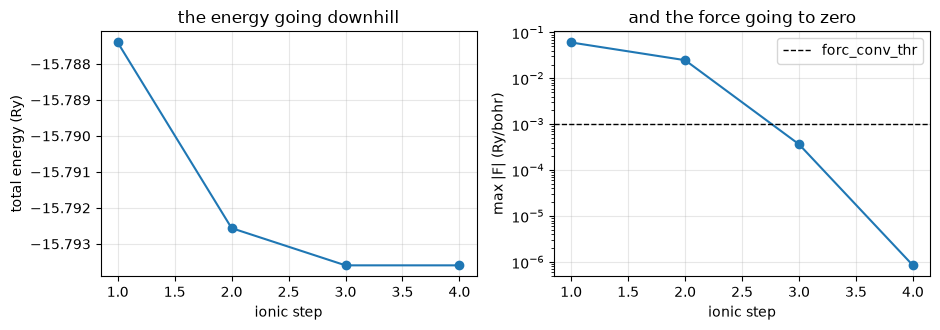

In [8]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.5, 3.4))
steps = [s.index for s in relaxed.steps]
left.plot(steps, [s.total_energy for s in relaxed.steps], 'o-')
left.set_xlabel('ionic step'); left.set_ylabel('total energy (Ry)')
left.set_title('the energy going downhill'); left.grid(alpha=0.3)

right.semilogy(steps, [max(s.max_force, 1e-12) for s in relaxed.steps], 'o-')
right.axhline(1e-3, ls='--', c='k', lw=1, label='forc_conv_thr')
right.set_xlabel('ionic step'); right.set_ylabel('max |F| (Ry/bohr)')
right.set_title('and the force going to zero'); right.legend(); right.grid(alpha=0.3)
fig.tight_layout()

Both atoms move: the forces on them are equal and opposite, so what returns to
(1/4, 1/4, 1/4) is their **separation**, while the pair drifts along x by half the
displacement. That is not a defect — a periodic crystal has no preferred origin, and the
total force being zero is the statement that it does not.

The SCF iteration counts fall along the trajectory. Two things are doing that. The density
of the previous geometry is a far better starting point than a superposition of atomic
charges, and it is carried across in the way `update_pot.f90` does it: the atomic
superposition is *moved* with the atoms and the difference between it and the converged
density — the part that took an SCF to find, and that barely changes when an atom moves a
hundredth of a bohr — is kept. And the SCF threshold follows the relaxation, tightening as
the forces shrink (`upscale`), because a force is a derivative and needs a better-converged
density than an energy does.

## 7. A molecule, a frozen atom, and the traps

QE's own relaxation test is a CO molecule in a 12 bohr box, ultrasoft, with the oxygen
frozen by the `0 0 0` flags on its `ATOMIC_POSITIONS` line. Those flags are `if_pos`, and
QE implements them by multiplying the force by them — so a frozen atom still *has* a force
and simply is not allowed to follow it.

In [9]:
QE_TREE = Path('../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite')
co_input = QE_TREE / 'pw_relax' / 'relax.in'
if co_input.is_file():
    co_system = build_system(read_pw_input(co_input))
    co_pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in co_system.structure.species)
    print('if_pos as parsed:', co_system.structure.if_pos)
    co = run_relax(co_system, co_pseudos, conv_thr=1e-10)
    co_reference = reference('pw_relax-relax')
    print(f'C-O bond   start {2.256:.6f}   relaxed {np.linalg.norm(co.positions[0] - co.positions[1]):.6f}'
          f'   QE {np.linalg.norm(co_reference.final_positions[0] - co_reference.final_positions[1]):.6f} bohr')
    print(f'the frozen oxygen moved by {np.abs(co.positions[1]).max():.1e} bohr')
    print(f'final energy   pypresso {co.total_energy:.10f}   QE {co_reference.final_energy:.10f}')
else:
    print('the vendored QE tree is not present; skipping the CO molecule')

if_pos as parsed: ((1, 1, 1), (0, 0, 0))


/u/40/ladovj1/data/Documents/programs/claude/pypresso/pypresso/workflows/relax.py:140: UserWarning: K_POINTS gamma asks for the half-sphere storage of the gamma-point trick, which is not implemented; running at an explicit k = 0 with the full G sphere instead. The result is the same, the cost is twice the plane waves
  calculation = calculation or Calculation(


C-O bond   start 2.256000   relaxed 2.140067   QE 2.140067 bohr
the frozen oxygen moved by 0.0e+00 bohr
final energy   pypresso -43.1097679955   QE -43.1097679953


### Three traps, all of them found the hard way

**The FFT grid and the symmetry group are chosen once and never re-derived.** QE's
`setup.f90` runs before the ionic loop, and `move_ions` only ever *checks* the symmetry
afterwards (`checkallsym`). The reason is sharp: the FFT dimensions must be a multiple of
the denominators of the crystal's fractional translations, so a geometry that breaks a
symmetry would be given a **different grid** — and the exchange-correlation energy is
evaluated pointwise on that grid, so the energy being minimised would jump by ~1e-6 Ry
between two steps of the same relaxation, for a reason that is not physics. A relaxation
whose objective function changes underneath it does not converge; it oscillates.
`Calculation.at_positions` is built around this: it rebuilds exactly what the structure
factor multiplies and shares everything else.

**A NaN that only exists in the gradient.** The Ewald sum's real-space part computes
`erfc(sqrt(alpha) r)/r` over neighbouring images and masks out the self term where `r = 0`.
Masking the *result* is enough for the energy and not for its derivative: `sqrt(0)` has an
infinite derivative, and `0 * inf` is NaN. The mask has to be applied to `r^2` **before**
the square root. Nothing in the energy tests could see this; the first force ever computed
came back as six NaNs.

**Which spin the density is in.** `sum_band.f90` converts the density to `(rho, m)` before
returning, so the `rho%of_r(:,1)` that `force_lc` is handed is the *total charge*. This
code stores `(up, down)` throughout, so the transcription has to sum the channels — and a
local force built from one channel is exactly half of the right answer, in a way no
unpolarized test can see. The oxygen molecule in the regression suite is there for this.

## 8. What it costs

A force evaluation is a fraction of one SCF iteration on either path — which is the number
that matters, because the SCF has to happen anyway and a relaxation costs what its ionic
steps cost.

The two paths are not equally cheap, and the reason is instructive. The transcription
consumes the density and the potential the SCF has just produced, exactly as
`forces.f90` consumes `rho%of_r` and `v%of_r`; the differentiated force cannot, because it
needs the density as a *function* of the positions, and rebuilding it is most of what it
pays for. Against Quantum ESPRESSO's own `forces` clock (in `PERFORMANCE.md`, where both
codes are pinned to one core) the transcription is at parity — 1.3x on the eight-atom cell
and 0.9x on the two-atom one — and the gradient is 3.4-3.8x slower, which is the same
factor this code pays on the SCF itself. Neither path is a new penalty.

In [10]:
import time

def timings(case):
    system, pseudos = load(case)
    calculation = Calculation(system, pseudos)
    start = time.perf_counter()
    scf = run_scf(system, pseudos, calculation=calculation, conv_thr=1e-10)
    per_iteration = (time.perf_counter() - start) / scf.iterations
    costs = {}
    for method in ('autodiff', 'analytic'):
        compute_forces(calculation, scf, method=method)          # compile
        start = time.perf_counter()
        compute_forces(calculation, scf, method=method)
        costs[method] = (time.perf_counter() - start) / per_iteration
    return per_iteration, costs

print(f"{'case':16s} {'s / SCF iteration':>18s} {'autodiff':>18s} {'analytic':>18s}")
for case in ['si2-us-force', 'si8-us']:
    per_iteration, costs = timings(case)
    print(f'{case:16s} {per_iteration:18.3f} '
          f"{costs['autodiff']:15.2f} it {costs['analytic']:15.2f} it")

case              s / SCF iteration           autodiff           analytic


si2-us-force                  0.228            0.24 it            0.06 it


si8-us                        0.420            0.50 it            0.17 it


Free, on either path, next to the SCF that has to happen anyway.

The transcription started out **eleven times slower than the gradient**, and the reason is
worth the paragraph. 91% of it was one term: `force_corr` was integrating the atomic charge
`rho_atomic(|G|)` once per *atom*, over all 36257 G-vectors, for a cell with eight atoms of
a single species — seven eighths of that work was the same integral again. The transform
depends on the species and not on the atom, which is why QE tabulates it once
(`init_tab_rhoat`); doing the same here took that term from 2902 ms to 5 ms. Compiling the
six terms as one function and consuming the SCF's own density did the rest.

A factor of thirty that was not in the algorithm, the arithmetic or the language — one
radial integration repeated per atom instead of per species, in the term whose value is the
smallest of the six. It is the argument for measuring rather than reasoning about cost, and
this file is not the first place in the project to make it.

---

**Where this leaves the project.** Forces close the loop between "what is the energy of
this structure" and "what structure is it". What is still missing on the same axis is the
**stress** — the derivative with respect to strain rather than position — which is the same
argument applied to the cell, and which `vc-relax` needs. The Miller indices are stored
rather than cartesian G-vectors precisely so that derivative exists (rule D2); the notebook
for it comes with P11.